## An analytic theory of convolutional neural network inverse problems solvers

This notebook demonstrates the main results of the paper "An analytic theory of convolutional neural network inverse problems solvers"

In [31]:
# Load packages
import sys 
sys.path.append('.') # Add project root to path  

import torch
from putils import show_images, get_dataset, TensorDataset, TensorDataLoader
from analytic import LocalEquivariantMMSE, get_operator, get_preinverse_operator   

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

torch.manual_seed(42)

### Prepare dataset 

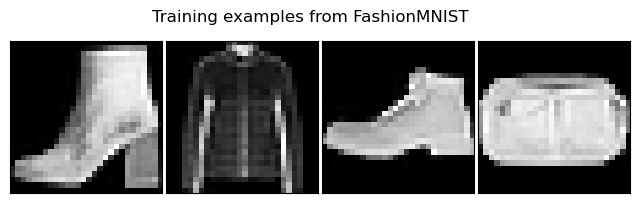

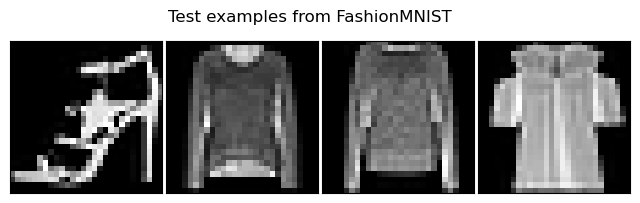

In [33]:
train_dataset = get_dataset("FashionMNIST", train=True, color=False)
# Extract a subset of 10k samples for faster demo
train_dataset = torch.utils.data.Subset(train_dataset, range(10000))


test_dataset = get_dataset("FashionMNIST", train=False, color=False)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=True)

# As we work with relatively small datasets, we can load all data into memory for faster analytical computations
train_tensors = []
for batch in train_loader:
    if isinstance(batch, (list, tuple)):
        batch = batch[0]
    train_tensors.append(batch)
    
train_tensors = torch.cat(train_tensors, dim=0).to(device=device, dtype=dtype)
train_dataset = TensorDataset(train_tensors)
train_loader = TensorDataLoader(train_dataset, batch_size=512, shuffle=False)

train_batch = next(iter(train_loader)).to(device=device, dtype=dtype)
test_batch = next(iter(test_loader))
if isinstance(test_batch, (list, tuple)):
    test_batch = test_batch[0]
test_batch = test_batch.to(device=device, dtype=dtype)

# Show some examples from the dataset
show_images(train_batch[:4], suptitle="Training examples from FashionMNIST", figsize=2)
show_images(test_batch[:4], suptitle="Test examples from FashionMNIST", figsize=2)

## Define the operator and the estimator

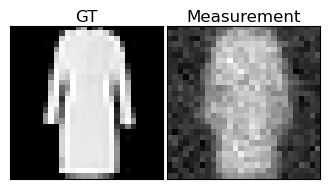

In [55]:
operator = "convolution_gaussian_1.0"   # options: "denoising", "inpainting_center_15", "convolution_gaussian_1.0"
pre_inverse_type = "identity" # options: "inverse", "epsilon_inverse"
img_size = test_batch.shape[1:]

# noise level 
sigma = 0.1

A = get_operator(operator, input_size=img_size, device=device, dtype=dtype)
B = get_preinverse_operator(operator, pre_inverse_type=pre_inverse_type, input_size=img_size, device=device, dtype=dtype)

i = 4
x = test_batch[i:i+1]  # select one test image
y = A(x) 
y = y + sigma * torch.randn_like(y)

show_images([x, y], title=["GT", "Measurement"], figsize=2)


## Compute the analytical LE-MMSE estimator

100%|██████████| 20/20 [00:01<00:00, 12.11it/s]


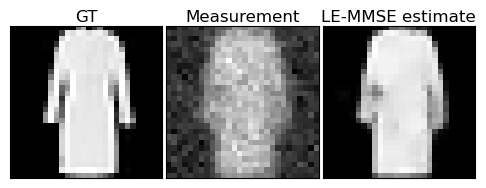

In [56]:
estimator = LocalEquivariantMMSE(patch_size=5, device=device, dtype=dtype)

x_hat = estimator.forward(y, A, B, data_loader=train_loader, sigma=sigma, verbose=True)
show_images([x, y, x_hat], title=["GT", "Measurement", "LE-MMSE estimate"], figsize=2)

## Compare with trained CNN solvers 

In [57]:
from model import load_pretrain_model

model = load_pretrain_model(
    model_type="unet2d",
    patch_size=5,
    dataset="FashionMNIST",
    color=False,
    operator=operator,
    preinverse_type=pre_inverse_type,
).to(device=device, dtype=dtype)

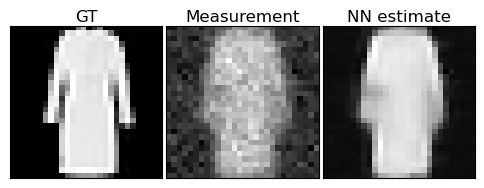

In [58]:
with torch.no_grad():
    x_nn_hat = model(B(y), sigma=sigma)
    
show_images([x, y, x_nn_hat], title=["GT", "Measurement", "NN estimate"], figsize=2)

## For varying noise levels


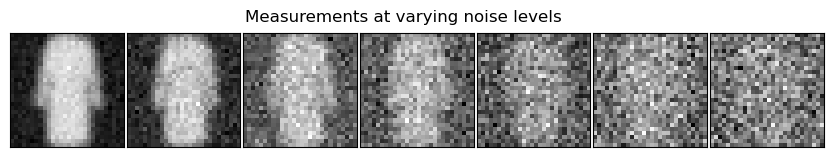

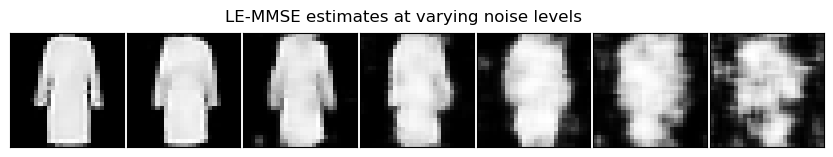

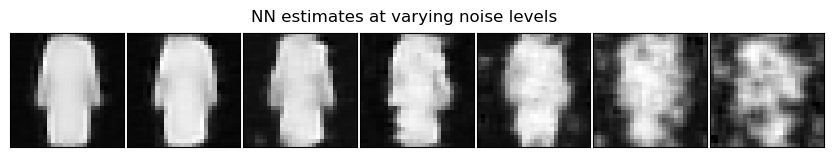

In [59]:
y_noiseless = A(x)
x_analytic = []
x_nn = []
measurements = []
for sigma in [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]:
    y = y_noiseless + sigma * torch.randn_like(y_noiseless)
    with torch.no_grad():
        x_hat = estimator.forward(y, A, B, data_loader=train_loader, sigma=sigma, verbose=False)
        x_nn_hat = model(B(y), sigma=sigma)
    x_analytic.append(x_hat)
    x_nn.append(x_nn_hat)
    measurements.append(y)

show_images(measurements, suptitle="Measurements at varying noise levels", figsize=1.5)
show_images(x_analytic, suptitle="LE-MMSE estimates at varying noise levels", figsize=1.5)
show_images(x_nn, suptitle="NN estimates at varying noise levels", figsize=1.5)

## LE-MMSE estimator is a patchwor of training patches

We illustrate here that the LE-MMSE estimator can be interpreted as a patchwor of training patches.


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:04<00:00,  4.30it/s]


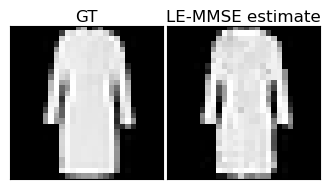

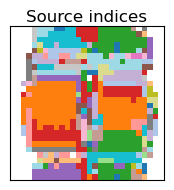

In [60]:
sigma = 0.05
operator = "denoising"

threshold = torch.tensor([0.5], device=device, dtype=dtype) # threshold for source indices
A = get_operator(operator, input_size=img_size, device=device, dtype=dtype)
B = get_preinverse_operator(operator, pre_inverse_type=pre_inverse_type, input_size=img_size, device=device, dtype=dtype)

estimator = LocalEquivariantMMSE(patch_size=11, device=device, dtype=dtype)

y_noiseless = A(x)
y = y_noiseless + sigma * torch.randn_like(y_noiseless)

# Set `return_distance=True` to compute distances between the test patch and training patches
output = estimator.forward(y, A, B, data_loader=train_loader, sigma=sigma, verbose=True, return_distance=True, topk=10000)


# Calculate effective samples
distances = output.distances
distances = torch.sort(distances, dim=0, descending=True).values

# Take the index of the max weight
indices = output.source_indices.view(x.shape)
                    
softmax = torch.softmax(distances, dim = 0) 
cum_softmax = torch.cumsum(softmax, dim = 0).t().contiguous()

threshold_expanded = threshold.expand_as(cum_softmax).contiguous()
num_effective = torch.searchsorted(cum_softmax, threshold_expanded).t().unique(dim=0) + 1
num_effective = num_effective.view(x.shape)

# Calculate the index that give more than threshold weight
source_indices = torch.where(num_effective == 1, indices, torch.inf)

show_images([x, output.estimate], title=["GT", "LE-MMSE estimate", "Source indices"], figsize=2)
show_images(source_indices.float(), title=["Source indices"], figsize=2, cmap='tab20')